##Data Visualization

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [ ]:
#load data and display
from google.colab import drive
drive.mount("/content/drive")
path_to_data_folder = "/content/drive/MyDrive"

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.chdir("/content/drive/MyDrive")

df = pd.read_csv('survey2.csv')
df.head()
df.info()

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-n

List of dropped columns: Timestamp, comments, 

mental_health_consequence
No       490
Maybe    477
Yes      292
Name: count, dtype: int64


<ipython-input-4-a6b656818768>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='mental_health_consequence', palette='coolwarm')


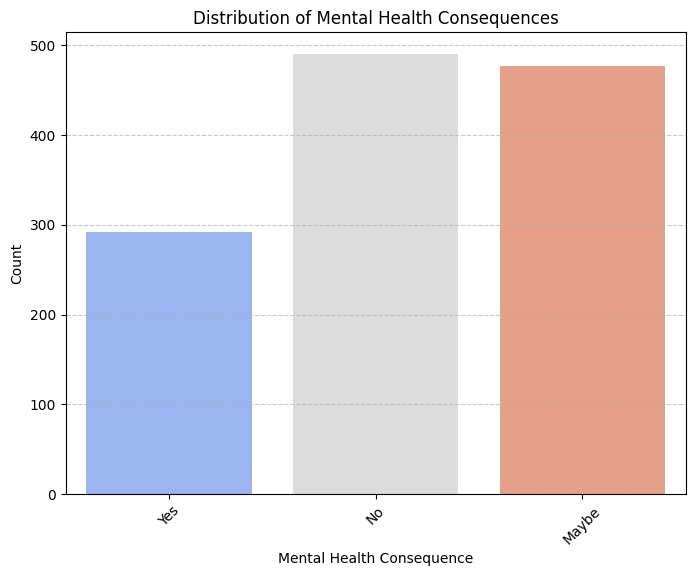

In [ ]:
#remove columns with too many missing values
df2 = df[[column for column in df if df[column].count() / len(df) >= 0.3]]
del df2['Timestamp']
print("List of dropped columns:", end=" ")
for c in df.columns:
    if c not in df2.columns:
        print(c, end=", ")
print('\n')
df = df2

#ensure ages are in a normal range
df = df[df['Age'] < 100]
df = df[df['Age'] > 0]

#visualization of output variable (`mental_health_consequence`)
print(df['mental_health_consequence'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='mental_health_consequence', palette='coolwarm')

plt.xlabel("Mental Health Consequence")
plt.ylabel("Count")
plt.title("Distribution of Mental Health Consequences")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

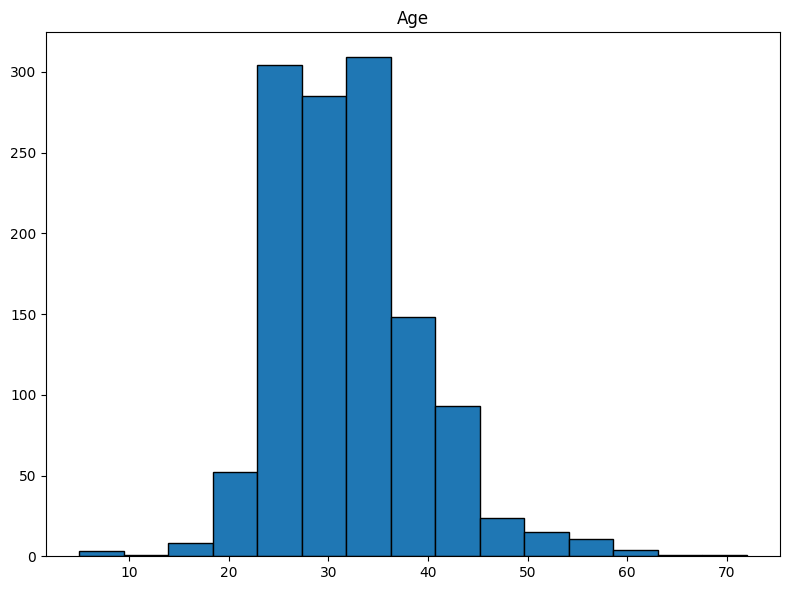

In [ ]:
#distribution analysis

#select the numerical featrues
num_features = df.select_dtypes(include = 'number')

num_features.hist(figsize=(8, 6), bins=15, edgecolor='black')
plt.tight_layout()
plt.grid(False)
plt.show()

There is 24 non numerical features including:
['Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence']


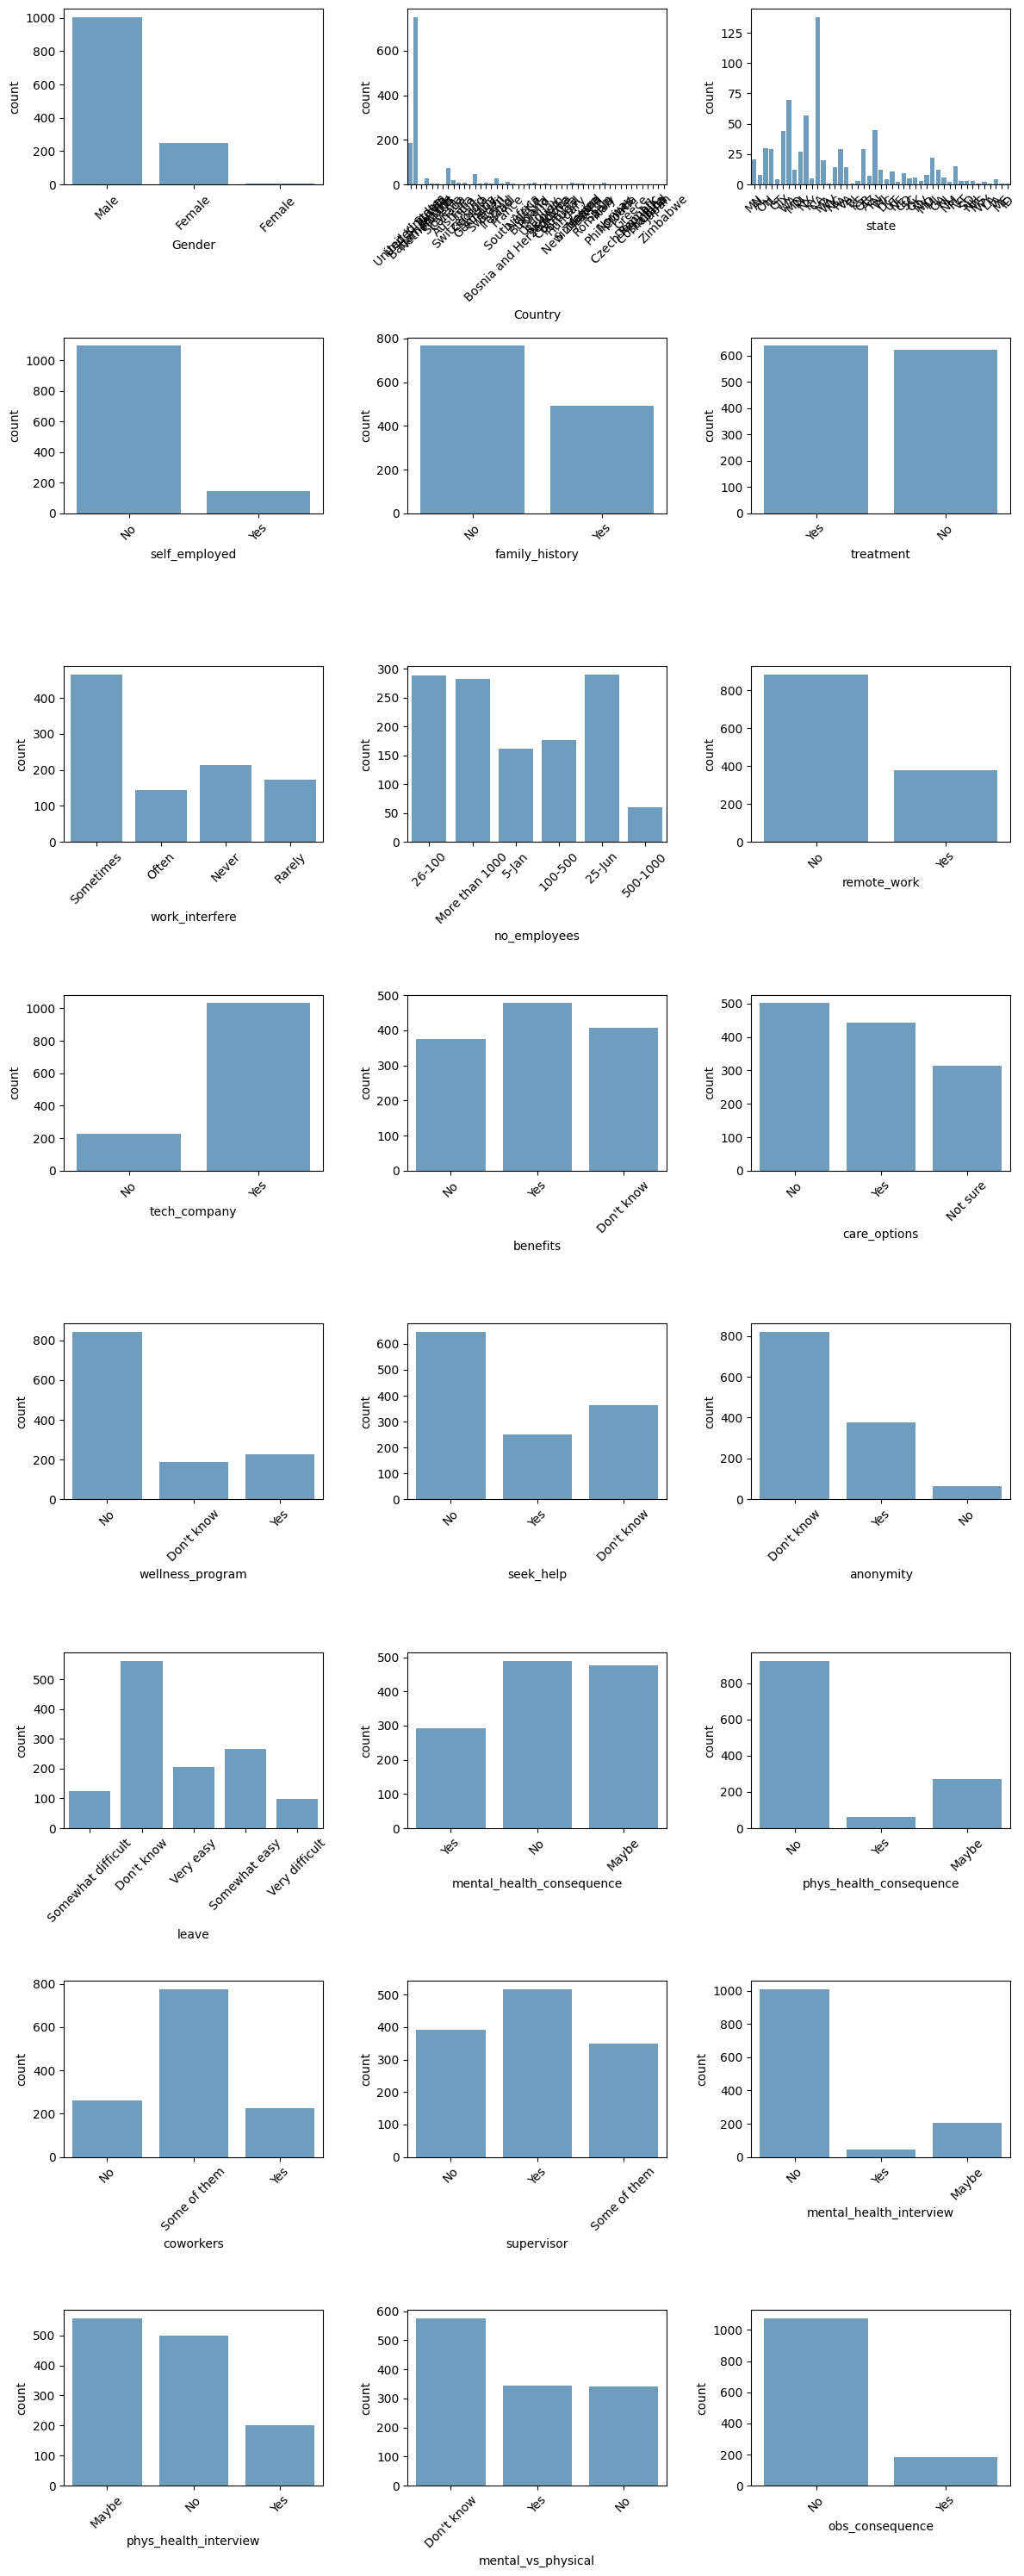

In [ ]:
#select categorical features
cate_features = df.select_dtypes(include = ['O'])
print('There is {} non numerical features including:\n{}'.format(len(cate_features.columns), cate_features.columns.tolist()))

fig, axes = plt.subplots(round(len(cate_features.columns) / 3), 3, figsize=(12, 30))

for i, ax in enumerate(fig.axes):
    if i < len(cate_features.columns):
        ax.tick_params(axis='x', rotation=45)
        sns.countplot(x=cate_features.columns[i], alpha=0.7, data=cate_features, ax=ax)

fig.tight_layout()

In [ ]:
#see the missings
df = pd.read_csv('survey2.csv')
y = df.mental_health_consequence
df.drop(['mental_health_consequence'], axis=1, inplace=True)

In [ ]:
df_na = df.isnull().sum() / len(df)
df_na = df_na[df_na > 0].sort_values(ascending=False)  #just keep the columns with missing values
print(df_na)

comments          0.869738
state             0.409055
work_interfere    0.209690
self_employed     0.014297
dtype: float64


Text(0.5, 1.0, 'Percent missing data by features')

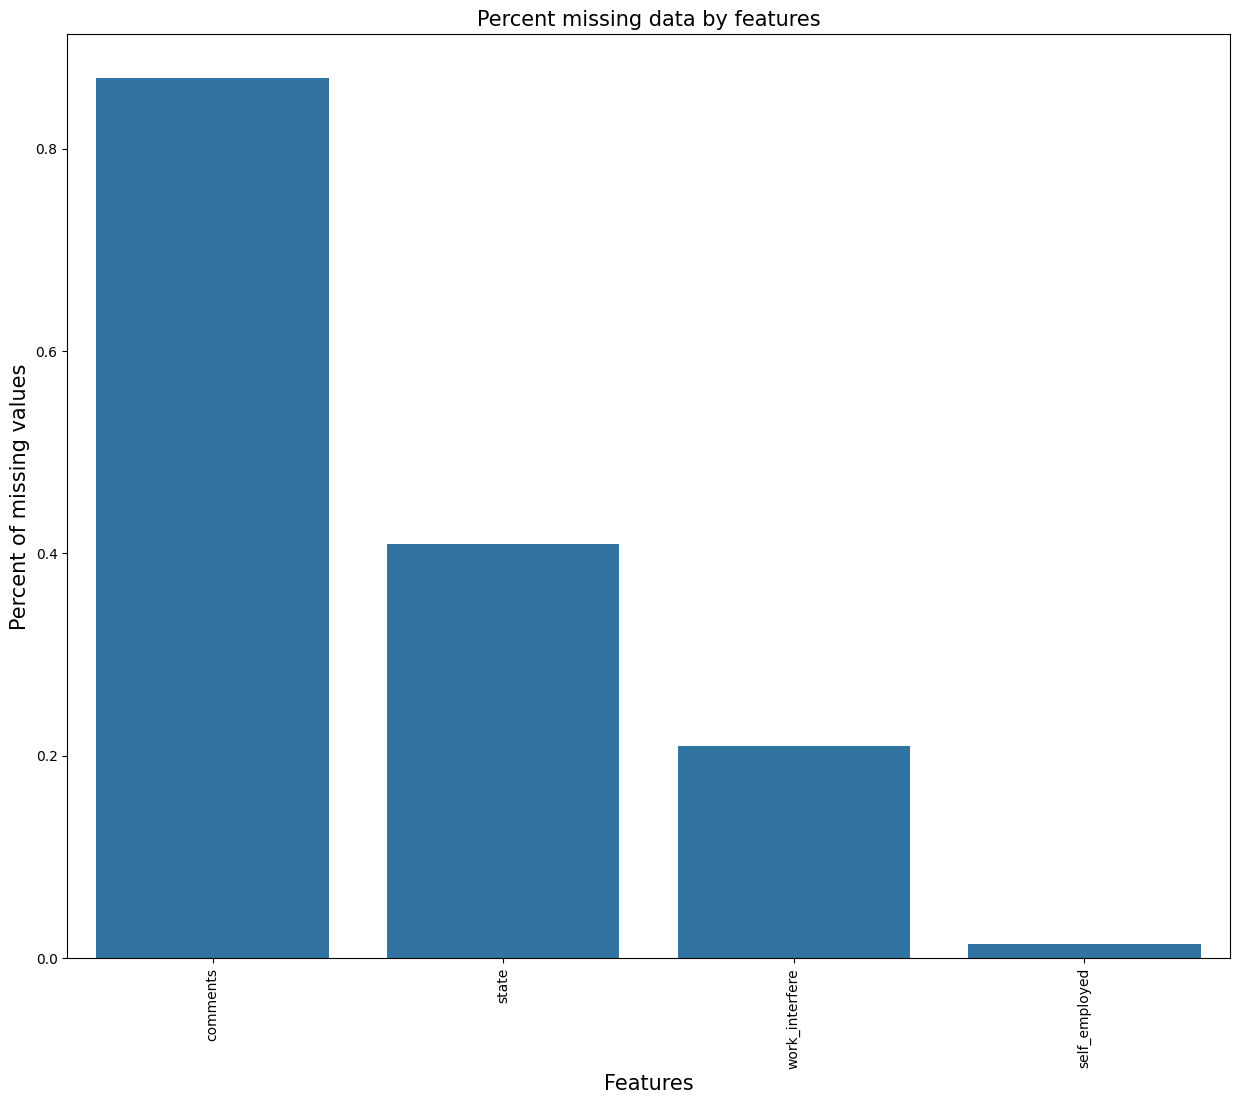

In [ ]:
#visualize the missing ratios
f, ax = plt.subplots(figsize=(15, 12))
plt.xticks(rotation=90)
sns.barplot(x=df_na.index, y=df_na)
plt.xlabel('Features', fontsize=15)
plt.ylabel('Percent of missing values', fontsize=15)
plt.title('Percent missing data by features', fontsize=15)

##Pre-Processing

In [ ]:
#remove columns with too many missing values
df2 = df[[column for column in df if df[column].count() / len(df) >= 0.3]]
del df2['Timestamp']
print("List of dropped columns:", end=" ")
for c in df.columns:
    if c not in df2.columns:
        print(c, end=", ")
print('\n')
df = df2

List of dropped columns: Timestamp, comments, 



In [ ]:
#replace with "None" (categorical features)
none_cols = ['Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees',
             'remote_work', 'tech_company', 'benefits', 'care_options','wellness_program','seek_help', 'anonymity', 'leave',
             'phys_health_consequence', 'coworkers', 'supervisor','mental_health_interview','phys_health_interview','mental_vs_physical',
             'obs_consequence']

for col in none_cols:
    df[col].fillna('None', inplace=True)


#replace with the median (for numerical features)
df['Age'] = df['Age'].transform(lambda x: x.fillna(x.median()))

<ipython-input-11-4288df3bf484>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('None', inplace=True)


In [ ]:
#check remaining missing values if any
df_na = (df.isnull().sum() / len(df)) * 100
df_na = df_na.drop(df_na[df_na == 0].index).sort_values(ascending=False)
missing_data = pd.DataFrame({'Missing Ratio' :df_na})
missing_data.head()

,Missing Ratio


In [ ]:
#feature engineering

from sklearn.preprocessing import LabelEncoder
cols = ('Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees',
             'remote_work', 'tech_company', 'benefits', 'care_options','wellness_program','seek_help', 'anonymity', 'leave',
             'phys_health_consequence', 'coworkers', 'supervisor','mental_health_interview','phys_health_interview','mental_vs_physical',
             'obs_consequence')
# process columns, apply LabelEncoder to categorical features
for c in cols:
    lbl = LabelEncoder()
    df[c] = lbl.fit_transform(df[c].astype(str))

print('Shape df: {}'.format(df.shape))


Shape df: (1259, 24)


In [ ]:
from scipy.stats import skew

numeric_feats = df.select_dtypes(include=[np.number]).columns

#find skew of each feature
skewed_feats = df[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
print("\nSkew in numerical features: \n")
skewness = pd.DataFrame({'Skew' :skewed_feats})
print(abs(skewness))


Skew in numerical features: 

                             Skew
self_employed            2.293121
obs_consequence          2.003386
remote_work              0.879901
Age                      0.861410
anonymity                0.752662
leave                    0.564131
phys_health_interview    0.483764
family_history           0.447664
mental_vs_physical       0.357633
no_employees             0.332223
seek_help                0.120423
care_options             0.087222
coworkers                0.017975
wellness_program         0.001455
treatment                0.023830
benefits                 0.103214
supervisor               0.186326
work_interfere           0.232738
phys_health_consequence  0.380836
mental_health_interview  0.722470
state                    0.783109
Gender                   1.508047
Country                  1.621167
tech_company             1.656223


In [ ]:
#find skewed features
skewed_features = skewness[abs(skewness) > 0.75]
skewed_features = skewed_features.dropna()
print(f"There are {len(skewed_features)} skewed numerical features to Box-Cox transform:")

from scipy.special import boxcox1p
skewed_features = skewed_features.index
lam = 0.15
for feat in skewed_features:
    df[feat] = boxcox1p(df[feat], lam)

There are 9 skewed numerical features to Box-Cox transform:


In [ ]:
#encode categorical variables as quantitative
df = pd.get_dummies(df)
print(df.shape)

(1259, 24)


In [ ]:
from sklearn.model_selection import train_test_split

#split training and test data
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.25, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression() #preliminary model for baseline comparison for feature selection
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

#print classification report for training
print("\nClassification Report on Train Set:")
print(classification_report(y_train, y_pred_train))

#print classification report for test
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred_test))


Classification Report on Train Set:
              precision    recall  f1-score   support

       Maybe       0.64      0.61      0.62       358
          No       0.73      0.81      0.76       363
         Yes       0.62      0.54      0.58       223

    accuracy                           0.67       944
   macro avg       0.66      0.65      0.66       944
weighted avg       0.67      0.67      0.67       944


Classification Report on Test Set:
              precision    recall  f1-score   support

       Maybe       0.54      0.58      0.56       119
          No       0.70      0.71      0.70       127
         Yes       0.50      0.42      0.46        69

    accuracy                           0.60       315
   macro avg       0.58      0.57      0.57       315
weighted avg       0.59      0.60      0.59       315



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Feature Selection

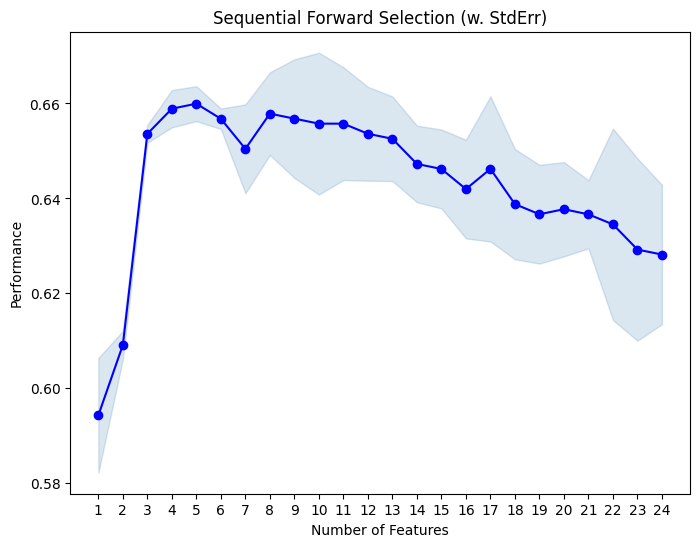

Selected Features: ['self_employed', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview']


In [ ]:
from sklearn.metrics import make_scorer, f1_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

#use SequentialFeatureSelector to run a step forward feature selection
sfs = SFS(model,
          k_features='best',  #let it decide the best number of features to select based on model performance
          forward=True,
          floating=False,
          scoring='accuracy', #use accuracy to score sfs because f1 score may not work due to class imbalance
          cv=3,
          n_jobs=-1)
sfs = sfs.fit(X_train, y_train)

plot_sfs(sfs.get_metric_dict(), kind='std_err', figsize=(8, 6)) #plot feature number against model performance
plt.title('Sequential Forward Selection (w. StdErr)')
plt.show()

selected_features = list(sfs.k_feature_names_) #print selected features
print("Selected Features:", selected_features)

In [ ]:
#split data into train and test sets using selected features
X_train, X_test, y_train, y_test = train_test_split(df[selected_features], y, test_size=0.2, random_state=0)
print(selected_features)

['self_employed', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview']


In [ ]:
model_selected_features = LogisticRegression() #preliminary model for baseline comparison for feature selection
model_selected_features.fit(X_train, y_train)

y_pred_train = model_selected_features.predict(X_train)
y_pred_test = model_selected_features.predict(X_test)

#print classification report for training
print("\nClassification Report on Train Set:")
print(classification_report(y_train, y_pred_train))

#print classification report for test
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred_test))


Classification Report on Train Set:
              precision    recall  f1-score   support

       Maybe       0.62      0.59      0.60       386
          No       0.71      0.81      0.75       396
         Yes       0.56      0.48      0.51       225

    accuracy                           0.65      1007
   macro avg       0.63      0.62      0.62      1007
weighted avg       0.64      0.65      0.64      1007


Classification Report on Test Set:
              precision    recall  f1-score   support

       Maybe       0.53      0.56      0.54        91
          No       0.71      0.76      0.73        94
         Yes       0.60      0.49      0.54        67

    accuracy                           0.62       252
   macro avg       0.61      0.60      0.61       252
weighted avg       0.61      0.62      0.61       252



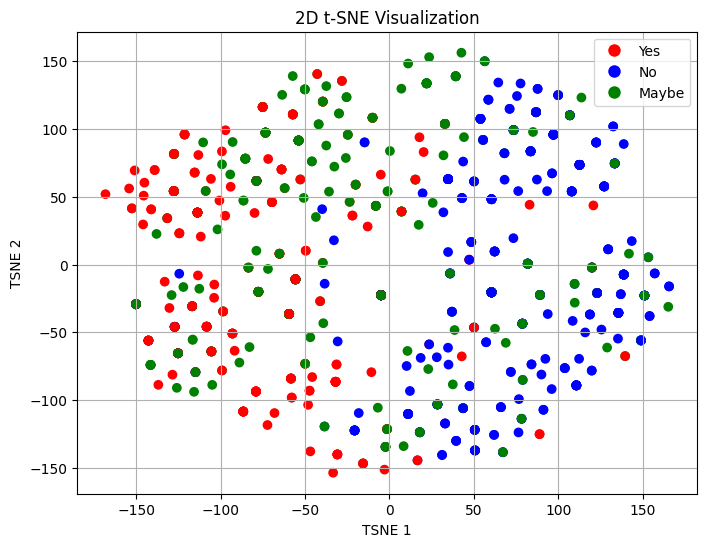

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import pandas as pd

#scale your data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df[selected_features])

#run t-SNE
tsne = TSNE(n_components=2, perplexity=300, random_state=42)
tsne_results = tsne.fit_transform(data_scaled)

#convert to dataframe for easy plotting
tsne_df = pd.DataFrame(tsne_results, columns=["TSNE1", "TSNE2"])
tsne_df["Label"] = y

#map string labels to colors
label_to_color = {
    "Yes": "red",
    "No": "blue",
    "Maybe": "green"
}
colors = tsne_df["Label"].map(label_to_color)

plt.figure(figsize=(8, 6))
plt.scatter(tsne_df["TSNE1"], tsne_df["TSNE2"], c=colors, alpha=1)
plt.title("2D t-SNE Visualization")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.grid(True)
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label=label, markersize=10, markerfacecolor=color)
    for label, color in label_to_color.items()
])
plt.show()

## Model Performance Comparison

In [ ]:
from sklearn.preprocessing import StandardScaler
#split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(df[selected_features], y, test_size=0.2, random_state=0)

#standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(y_train.shape)

(1007, 5)
(1007,)


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

#models
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier()
}

#hyperparameter tuning for each model
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ['liblinear', 'saga']
    },
    "SVM": {
        "C": [0.1, 1, 10, 100],
        "kernel": ['linear', 'rbf'],
        "gamma": ['scale', 'auto']
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 10],
        "weights": ['uniform', 'distance'],
        "metric": ['euclidean', 'manhattan']
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    }
}

best_model = None
best_score = 0
best_params = None

#scoring matrix
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, average='weighted'),
    "recall": make_scorer(recall_score, average='weighted'),
    "f1": make_scorer(f1_score, average='weighted')
}

best_model = None
best_score = 0
best_params = None
results = {}

for name, model in models.items():
    print(f"Optimizing {name}...")
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring=scoring, refit='f1', n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)

    #get the best model and scores
    best_estimator = grid_search.best_estimator_
    best_params_model = grid_search.best_params_

    #evaluate on test set
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    y_pred = best_estimator.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"{name} - Best Parameters: {best_params_model}")
    print(f"{name} - Test Accuracy: {acc:.4f}")
    print(f"{name} - Test Precision: {prec:.4f}")
    print(f"{name} - Test Recall: {rec:.4f}")
    print(f"{name} - Test F1 Score: {f1:.4f}\n")

    #save for comparison later
    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "Params": best_params_model
    }

    if f1 > best_score:
        best_score = f1
        best_model = name
        best_params = best_params_model

#print overall best
print(f"Best Model: {best_model}")
print(f"Best F1 Score: {best_score:.4f}")
print(f"Best Model Parameters: {best_params}")

Optimizing Logistic Regression...
Logistic Regression - Best Parameters: {'C': 1, 'solver': 'saga'}
Logistic Regression - Test Accuracy: 0.6151
Logistic Regression - Test Precision: 0.6142
Logistic Regression - Test Recall: 0.6151
Logistic Regression - Test F1 Score: 0.6128

Optimizing SVM...
SVM - Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
SVM - Test Accuracy: 0.5992
SVM - Test Precision: 0.6001
SVM - Test Recall: 0.5992
SVM - Test F1 Score: 0.5959

Optimizing KNN...
KNN - Best Parameters: {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'uniform'}
KNN - Test Accuracy: 0.6151
KNN - Test Precision: 0.6161
KNN - Test Recall: 0.6151
KNN - Test F1 Score: 0.6137

Optimizing Random Forest...
Random Forest - Best Parameters: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
Random Forest - Test Accuracy: 0.6230
Random Forest - Test Precision: 0.6300
Random Forest - Test Recall: 0.6230
Random Forest - Test F1 Score: 0.6211

Best Mod

##Neural networks

In [ ]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 26.9 MB/s eta 0:00:00


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

#split into training and test sets
X_train_, X_test, y_train_, y_test = train_test_split(df[selected_features].to_numpy(), y, stratify=y, random_state=42)

#further split training into training and validation
X_train, X_val, y_train, y_val = train_test_split(X_train_, y_train_, stratify=y_train_, random_state=42)

#define hyperparameter grid
learning_rates = [0.001, 0.01, 0.1]
hidden_layer_sizes = [(10,), (50,), (100,), (10, 10), (50, 50), (100, 100)]

#track the best model
best_score = 0
best_params = {}

#grid search
for hls in hidden_layer_sizes:
    for lr in learning_rates:
        mlp = MLPClassifier(
            solver='adam',
            random_state=0,
            hidden_layer_sizes=hls,
            learning_rate_init=lr,
            max_iter=5000
        )
        mlp.fit(X_train, y_train)
        score = mlp.score(X_val, y_val)
        if score > best_score:
            best_score = score
            best_params = {'learning_rate': lr, 'hidden_layer_sizes': hls}

#print only the best found configuration
print("Best Validation Score: %f" % best_score)
print("Best Parameters:", best_params)

#train a final model with best parameters
mlp = MLPClassifier(
    solver='adam',
    random_state=0,
    hidden_layer_sizes=best_params['hidden_layer_sizes'],
    learning_rate_init=best_params['learning_rate'],
    max_iter=5000
)
mlp.fit(X_train_, y_train_)
test_accuracy = mlp.score(X_test, y_test)
y_pred = mlp.predict(X_test)

#compute precision, recall, F1
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

#output metrics
print("Test Set Accuracy: %f" % test_accuracy)
print("Test Set Precision (weighted): %f" % precision)
print("Test Set Recall (weighted): %f" % recall)
print("Test Set F1 Score (weighted): %f" % f1)

Best Validation Score: 0.669492
Best Parameters: {'learning_rate': 0.01, 'hidden_layer_sizes': (10,)}
Test Set Accuracy: 0.723810
Test Set Precision (weighted): 0.720161
Test Set Recall (weighted): 0.723810
Test Set F1 Score (weighted): 0.721050


##Feature Importance

In [ ]:
#split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(df[selected_features], y, test_size=0.2, random_state=0)

#standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

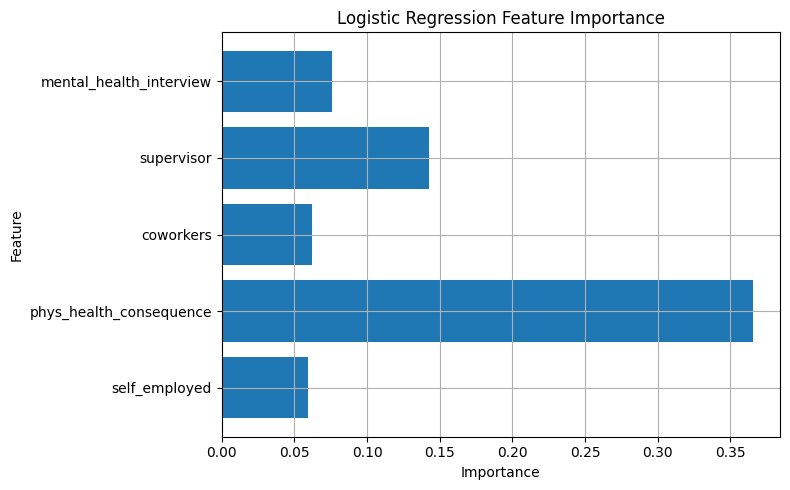

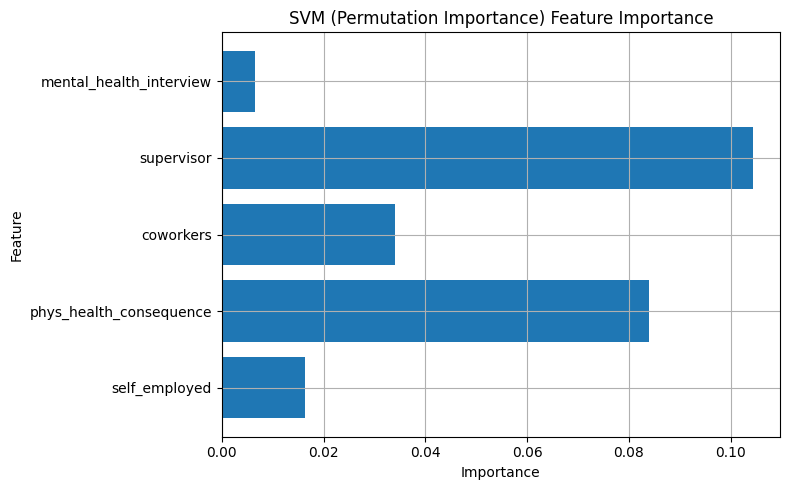

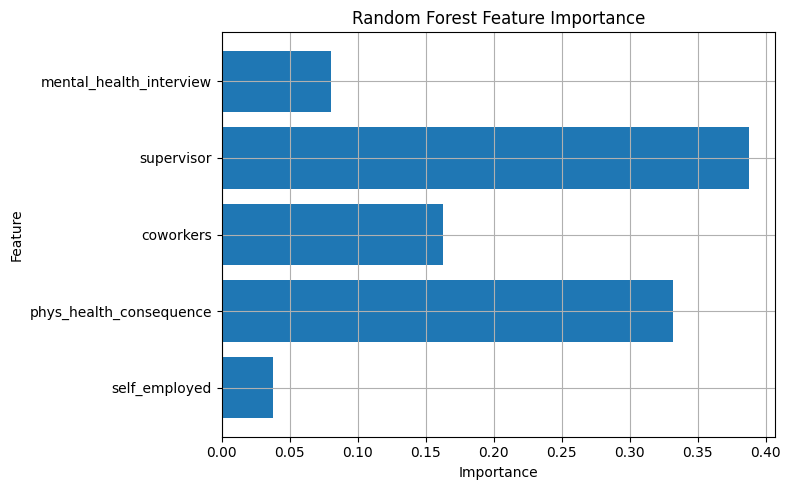

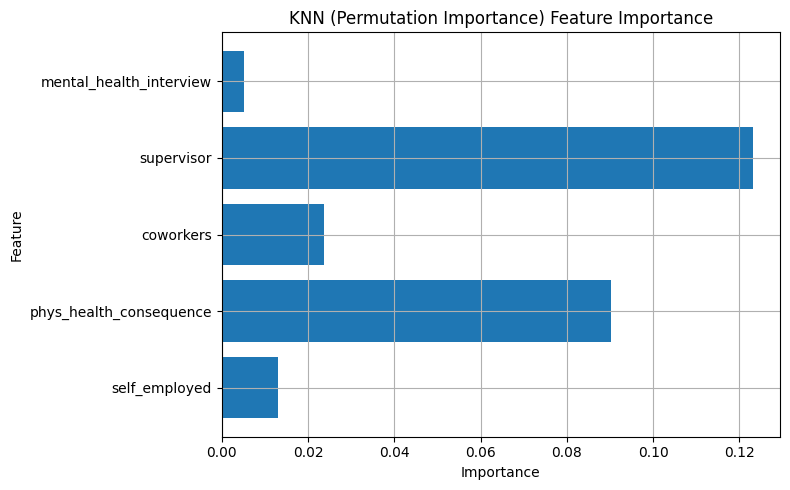

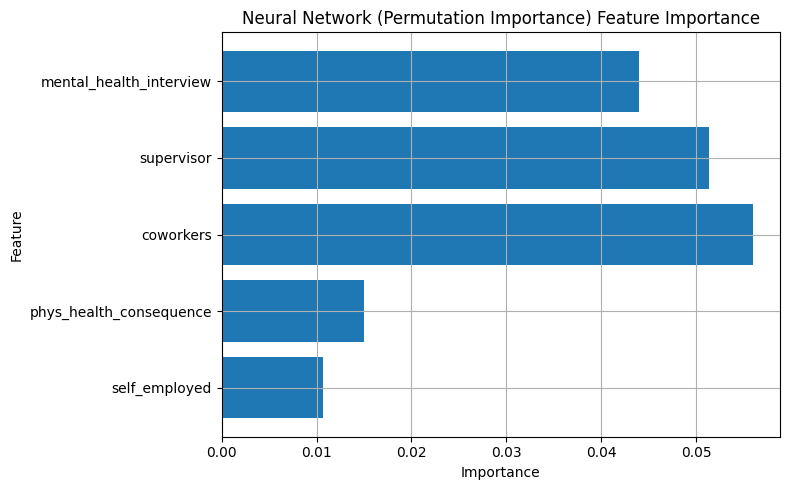

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

#store all best estimators
best_estimators = {
    "Logistic Regression": models["Logistic Regression"].set_params(C= 1, solver= 'saga').fit(X_train_scaled, y_train),
    "SVM": models["SVM"].set_params(C= 0.1, gamma= 'scale', kernel= 'rbf').fit(X_train_scaled, y_train),
    "KNN": models["KNN"].set_params(metric= 'manhattan', n_neighbors= 10, weights= 'uniform').fit(X_train_scaled, y_train),
    "Random Forest": models["Random Forest"].set_params(max_depth= 10, min_samples_leaf= 4, min_samples_split= 10, n_estimators= 50).fit(X_train_scaled, y_train),
    "Neural Network": mlp
}

#plotting function
def plot_importance(title, feature_names, importances):
    plt.figure(figsize=(8, 5))
    plt.barh(feature_names, importances)
    plt.title(f"{title} Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#logistic Regression (use absolute coef)
lr = best_estimators["Logistic Regression"]
lr_importance = np.abs(lr.coef_[0])
plot_importance("Logistic Regression", selected_features, lr_importance)

#SVM
svm = best_estimators["SVM"]
svm_perm = permutation_importance(svm, X_test_scaled, y_test, scoring='f1_weighted', n_repeats=10, random_state=42)
plot_importance("SVM (Permutation Importance)", selected_features, svm_perm.importances_mean)

#random Forest
rf = best_estimators["Random Forest"]
rf_importance = rf.feature_importances_
plot_importance("Random Forest", selected_features, rf_importance)

#KNN with permutation importance
knn = best_estimators["KNN"]
knn_perm = permutation_importance(knn, X_test_scaled, y_test, scoring='f1_weighted', n_repeats=10, random_state=42)
plot_importance("KNN (Permutation Importance)", selected_features, knn_perm.importances_mean)

#Neural network with permutation importance
nn = best_estimators["Neural Network"]
nn_perm = permutation_importance(nn, X_test_scaled, y_test, scoring='f1_weighted', n_repeats=10, random_state=42)
plot_importance("Neural Network (Permutation Importance)", selected_features, nn_perm.importances_mean)

